In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import loguniform, uniform, randint

from sklearn.model_selection import RandomizedSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.svm import SVC, LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold, KFold, GridSearchCV, RandomizedSearchCV

## Data Engineering

### Import des données

In [4]:
df = pd.read_excel("Datasets/credit_card.xls", header=1)
df

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29995,29996,220000,1,3,1,39,0,0,0,0,...,88004,31237,15980,8500,20000,5003,3047,5000,1000,0
29996,29997,150000,1,3,2,43,-1,-1,-1,-1,...,8979,5190,0,1837,3526,8998,129,0,0,0
29997,29998,30000,1,2,2,37,4,3,2,-1,...,20878,20582,19357,0,0,22000,4200,2000,3100,1
29998,29999,80000,1,3,1,41,1,-1,0,0,...,52774,11855,48944,85900,3409,1178,1926,52964,1804,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          30000 non-null  int64
 1   LIMIT_BAL                   30000 non-null  int64
 2   SEX                         30000 non-null  int64
 3   EDUCATION                   30000 non-null  int64
 4   MARRIAGE                    30000 non-null  int64
 5   AGE                         30000 non-null  int64
 6   PAY_0                       30000 non-null  int64
 7   PAY_2                       30000 non-null  int64
 8   PAY_3                       30000 non-null  int64
 9   PAY_4                       30000 non-null  int64
 10  PAY_5                       30000 non-null  int64
 11  PAY_6                       30000 non-null  int64
 12  BILL_AMT1                   30000 non-null  int64
 13  BILL_AMT2                   30000 non-null  int64
 14  BILL_A

### Tri de nos données

#### On supprime les données dont le statut marital = 0
Cette valeur n'est pas présente dans la légende du dataset. On sait juste que (1 = marié; 2 = seule; 3 = autres).<br>
De plus, il n'y a que 54 échantillons qui ont un statut marital=0. Cele est sûrement une anomalie dans le dataset

In [10]:
np.unique(df["MARRIAGE"])

array([0, 1, 2, 3], dtype=int64)

In [11]:
print("Quantité d'échantillon dont le statut marital vaut zéro : ", len(df[df["MARRIAGE"]==0]))

Quantité d'échantillon dont le statut marital vaut zéro :  54


In [12]:
df = df[df["MARRIAGE"]!=0]
len(df)

29946

#### Idem pour le niveau d'études des individus.
On est normalement censé avoir : (1 = Niveau Master/Doctorat; 2 = Université; 3 = Lycée; 4 = Autres).<br>
Cependant on a des nouvelles valeurs qui se se sont glissées sans réelles signification

In [14]:
df["EDUCATION"].unique()

array([2, 1, 3, 5, 4, 6, 0], dtype=int64)

In [15]:
print(
    "Nombre d'anomalies dans la feature du niveau d'études : ",
    len(df[ (df["EDUCATION"] == 0) | (df["EDUCATION"] == 5) | (df["EDUCATION"] == 6)]))

Nombre d'anomalies dans la feature du niveau d'études :  345


In [16]:
# On enlève les anomalies
df = df[ (df["EDUCATION"] != 0) & (df["EDUCATION"] != 5) & (df["EDUCATION"] != 6)]
len(df["EDUCATION"])

29601

### Visualisation des données

#### On analyse la proportion de personnes étant en défauts de paiement ou non pour le mois prochain

([<matplotlib.patches.Wedge at 0x27e87997560>,
 [Text(-0.8406193327575661, 0.7094780739347938, '0'),
  Text(0.8406193659706304, -0.7094780345825623, '1')],
 [Text(-0.45851963604958146, 0.38698804032806927, '77.7%'),
  Text(0.4585196541657983, -0.38698801886321577, '22.3%')])

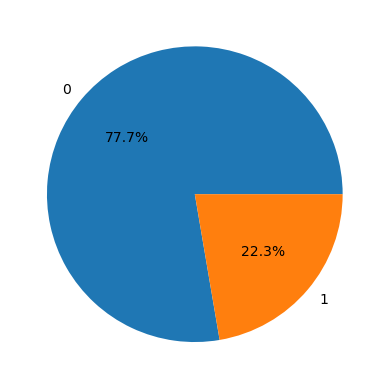

In [27]:
unique, counts = np.unique(df.iloc[:, -1], return_counts=True)
plt.pie(counts, labels=unique, autopct='%1.1f%%')

Text(0, 0.5, 'Nombre')

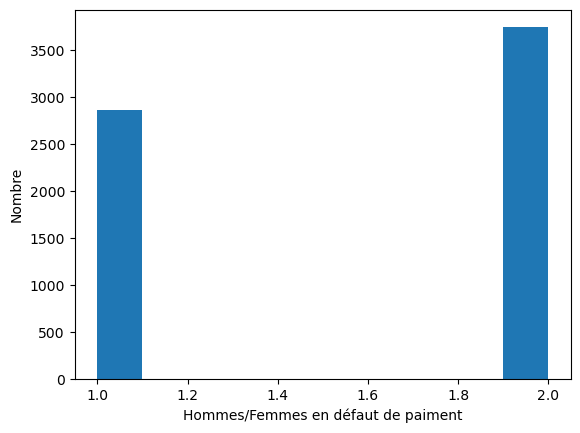

In [28]:
plt.hist(df["SEX"][df["default payment next month"]==1])
plt.xlabel("Hommes/Femmes en défaut de paiment")
plt.ylabel("Nombre")

Text(0, 0.5, 'Nombre')

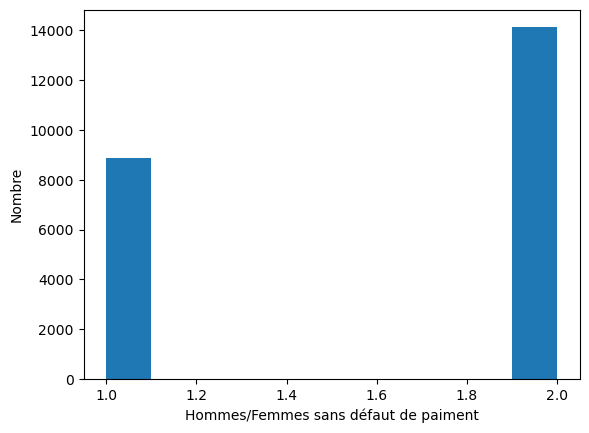

In [30]:
plt.hist(df["SEX"][df["default payment next month"]==0])
plt.xlabel("Hommes/Femmes sans défaut de paiment")
plt.ylabel("Nombre")

#### Analysons la quantité d'hommes et de femmes dans le dataset

([<matplotlib.patches.Wedge at 0x27e87951a60>,
 [Text(0.35038274124816504, 1.0427041453046122, '1'),
  Text(-0.35038264362315596, -1.0427041781098072, '2')],
 [Text(0.19111785886263546, 0.5687477156206975, '39.7%'),
  Text(-0.1911178056126305, -0.5687477335144403, '60.3%')])

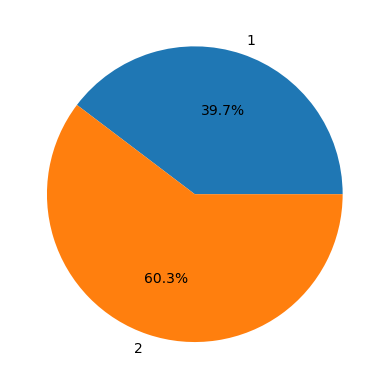

In [34]:
unique_sxe, count_sxe = np.unique(df[["SEX"]], return_counts=True)
plt.pie(count_sxe, autopct='%1.1f%%', labels=unique_sxe)

<blockquote>On remarque que les femmes sont dominantes dans le jeu de données. <br> Le sexe des individus pourrait être utile. Les femmes ont plus de crédit bancaires que les hommes dans ce jeu de données (60% de femmes contre 40% d'hommes)</blockquote>

#### Age par rapport au montant du crédit avec leur situation de paiement (défaut de paiement ou non)

In [38]:
df["MARRIAGE"].unique()

array([1, 2, 3], dtype=int64)

Text(0, 0.5, 'Montant du crédit')

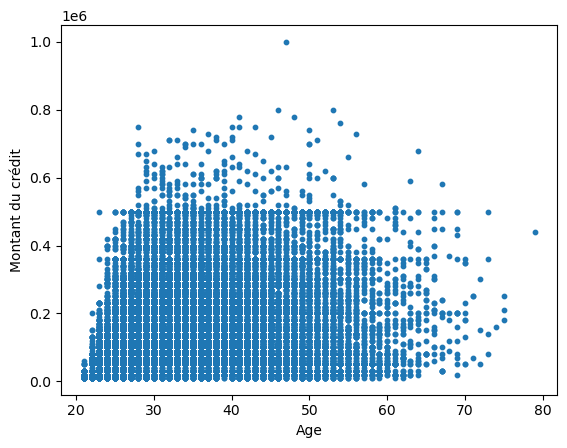

In [40]:
plt.scatter(df[["AGE"]], df[["LIMIT_BAL"]], s=10)
plt.xlabel("Age")
plt.ylabel("Montant du crédit")

#### Séparation de nos données

In [26]:
target = df[["default payment next month"]]
target = target.to_numpy().ravel()   # On le transforme en array  pour éviter des bugs lors de l'entraînement
target

array([1, 1, 0, ..., 1, 1, 1], dtype=int64)

In [28]:
data = df.drop(["ID", "default payment next month"], axis=1)
data.head()

,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6
0,20000,2,2,1,24,2,2,-1,-1,-2,...,689,0,0,0,0,689,0,0,0,0
1,120000,2,2,2,26,-1,2,0,0,0,...,2682,3272,3455,3261,0,1000,1000,1000,0,2000
2,90000,2,2,2,34,0,0,0,0,0,...,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000
3,50000,2,2,1,37,0,0,0,0,0,...,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000
4,50000,1,2,1,57,-1,0,-1,0,0,...,35835,20940,19146,19131,2000,36681,10000,9000,689,679


#### Matrice de corrélation

<Axes: >

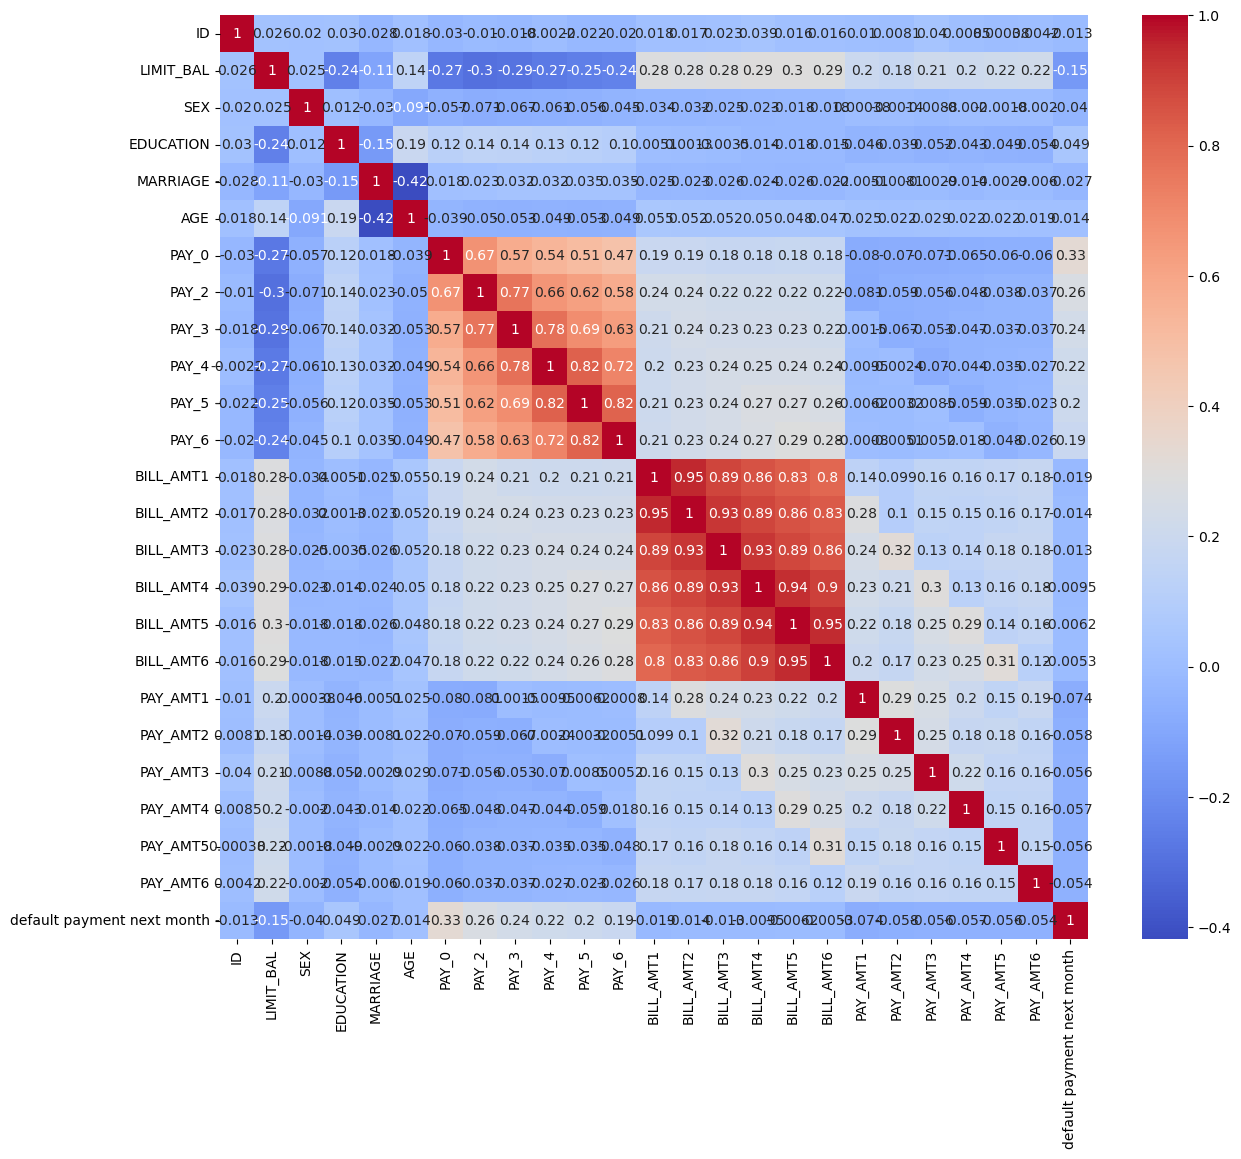

In [31]:
plt.figure(figsize=(14, 12))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

#### Entraînement d'un arbre de classification simple afin de voir l'importance de chaque features

In [50]:
tree = DecisionTreeClassifier(max_depth=None)

In [51]:
tree.fit(data, target)

DecisionTreeClassifier()

In [53]:
importances = pd.Series(tree.feature_importances_, index=data.columns)
importances.sort_values(ascending=False)

PAY_0        0.164423
AGE          0.076140
BILL_AMT1    0.067605
LIMIT_BAL    0.054918
PAY_AMT3     0.051996
BILL_AMT6    0.050368
BILL_AMT2    0.049660
BILL_AMT3    0.048494
PAY_AMT2     0.047849
PAY_AMT6     0.047588
PAY_AMT1     0.045365
BILL_AMT5    0.045024
PAY_AMT4     0.043857
BILL_AMT4    0.043587
PAY_AMT5     0.041198
PAY_2        0.035974
EDUCATION    0.018882
PAY_3        0.012847
MARRIAGE     0.012460
PAY_6        0.011615
SEX          0.011462
PAY_5        0.009415
PAY_4        0.009275
dtype: float64

<blockquote>Nous allons garder toutes les features car chacune est importante quant à la prédiction d'un défaut de paiement. <br> Chaque variable nous donne des informations sur chaque individu et sur sa situation de vie. Donc, par précaution, ne négligeons aucune variable qui pourrait s'avérer être utile. </blockquote>

## Entraînement de modèles

### Train_Test_Split
<blockquote>
On compte faire un double passage dans notre RandomizedSearchCV.<br>
On va initialiser un n_iter large  sur un petit échantillon de données (X_train_small, Y_train_small). <br>
Puis on va affiner nos hyperparamètres dans la zone prometteuse trouvée sur un plus grand jeu de données (X_train_small, Y_train_small).
</blockquote>

In [271]:
#Large split
X_train_large, X_test, Y_train_large, Y_test = train_test_split(
    data, target, train_size=0.1, random_state=42, stratify=target
)

#Petit split
X_train_petit, _, Y_train_petit, _ = train_test_split(
    X_train_large, Y_train_large, train_size=0.30, stratify=Y_train_large
)

Grand dataset :  2960
Petit dataset :  888


(array([690.,   0.,   0.,   0.,   0.,   0.,   0.,   0.,   0., 198.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

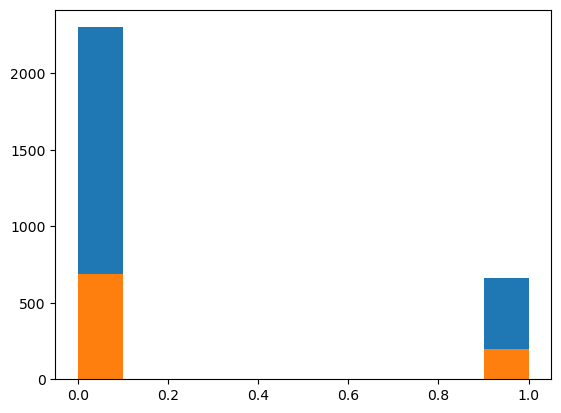

In [273]:
print("Grand dataset : ", len(Y_train_large))
plt.hist(Y_train_large)

print("Petit dataset : ", len(Y_train_petit))
plt.hist(Y_train_petit)

In [277]:
np.unique(X_train_large[["PAY_0"]], return_counts=True)

(array([-2, -1,  0,  1,  2,  3,  4,  5,  7,  8], dtype=int64),
 array([ 256,  580, 1449,  363,  269,   30,    8,    2,    1,    2],
       dtype=int64))

In [285]:
print("X_train_large PAY_0 : ", len(np.unique(X_train_large[["PAY_0"]])))
print("X_train_petit PAY_0 : ", len(np.unique(X_train_petit[["PAY_0"]])))

for i in range(2, 7):

    xtl_unique, xtl_counts = np.unique(np.unique(X_train_large[[f"PAY_{i}"]]), return_counts=True)
    xtp_unique, xtp_counts = np.unique(np.unique(X_train_petit[[f"PAY_{i}"]]), return_counts=True)
    
    print(f"X_train_large PAY_{i} : ", len(xtl_unique))
    print(f"X_train_petit PAY_{i} : ", len(xtp_unique))

X_train_large PAY_0 :  10
X_train_petit PAY_0 :  9
X_train_large PAY_2 :  9
X_train_petit PAY_2 :  7
X_train_large PAY_3 :  9
X_train_petit PAY_3 :  7
X_train_large PAY_4 :  8
X_train_petit PAY_4 :  7
X_train_large PAY_5 :  8
X_train_petit PAY_5 :  6
X_train_large PAY_6 :  9
X_train_petit PAY_6 :  6


In [263]:
data

Index(['LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2',
       'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6'],
      dtype='object')

### Preprocessing & Pipelines

#### Preprocessing

In [48]:
onehot_features = ["SEX", "EDUCATION", "MARRIAGE"]
std_features = data.columns.drop(onehot_features)

preprocessor = ColumnTransformer(
    transformers = [
        ('ohe', OneHotEncoder(), onehot_features),
        ('std', StandardScaler(), std_features)
    ],
    remainder = "passthrough"
)

In [50]:
std_features

Index(['LIMIT_BAL', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5',
       'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4',
       'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3',
       'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6'],
      dtype='object')

#### Pipeline du SVC

In [53]:
pipeline_svc = Pipeline([
    ('preprocess', preprocessor),
    ('svc', SVC())
])

### RandomizedSearchCV pour un SVC

#### Randomized Search CV (petit échantillon + beaucoup d'itérations)

In [119]:
param_distrib_svc = [
    {
        'svc__C' : loguniform(1e-3, 100),
        'svc__kernel' : ['rbf'],
        'svc__gamma' : ['scale', 'auto']
        
    },
    {
        'svc__C' :  loguniform(5, 20),
        'svc__kernel' : ['poly'],
        'svc__degree' : randint(2, 6),
        'svc__gamma' : ['scale', 'auto']
    }
]
    

In [129]:
random_grid_svc_1 = RandomizedSearchCV(
    estimator = pipeline_svc,
    param_distributions = param_distrib_svc, 
    n_iter = 100,       # Premier randomsearchcv avec 30 iterations sur un échantillon 
    scoring = 'accuracy',
    cv = 4,
    n_jobs=-1
)

In [131]:
random_grid_svc_1.fit(X_train_petit, Y_train_petit)

RandomizedSearchCV(cv=4,
                   estimator=Pipeline(steps=[('preprocess',
                                              ColumnTransformer(remainder='passthrough',
                                                                transformers=[('ohe',
                                                                               OneHotEncoder(),
                                                                               ['SEX',
                                                                                'EDUCATION',
                                                                                'MARRIAGE']),
                                                                              ('std',
                                                                               StandardScaler(),
                                                                               Index(['LIMIT_BAL', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5',
       'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4',
       'BILL_AMT5', 'BILL_AMT6', 'PAY_A...
                   param_distributions=[{'svc__C': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x000001E44DD18C50>,
                                         'svc__gamma': ['scale', 'auto'],
                                         'svc__kernel': ['rbf']},
                                        {'svc__C': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x000001E44DD2E990>,
                                         'svc__degree': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x000001E44E8706E0>,
                                         'svc__gamma': ['scale', 'auto'],
                                         'svc__kernel': ['poly']}],
                   scoring='accuracy')

In [132]:
best_params_small_xtrain = random_grid_svc_1.best_params_
best_params_small_xtrain

{'svc__C': 2.2450565727046885, 'svc__gamma': 'auto', 'svc__kernel': 'rbf'}

#### Randomized Search CV (plus grand échantillon + peu d'itérations)

In [142]:
random_grid_svc_2 = RandomizedSearchCV(
    estimator = pipeline_svc,
    param_distributions = param_distrib_svc, 
    n_iter = 20,       # Deuxième randomsearchcv avec 0 iterations sur un échantillon 
    scoring = 'accuracy',
    cv = 4,    
    n_jobs=-1
)

In [144]:
random_grid_svc_2.fit(X_train_large, Y_train_large)

RandomizedSearchCV(cv=4,
                   estimator=Pipeline(steps=[('preprocess',
                                              ColumnTransformer(remainder='passthrough',
                                                                transformers=[('ohe',
                                                                               OneHotEncoder(),
                                                                               ['SEX',
                                                                                'EDUCATION',
                                                                                'MARRIAGE']),
                                                                              ('std',
                                                                               StandardScaler(),
                                                                               Index(['LIMIT_BAL', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5',
       'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4',
       'BILL_AMT5', 'BILL_AMT6', 'PAY_A...
                   param_distributions=[{'svc__C': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x000001E44DD18C50>,
                                         'svc__gamma': ['scale', 'auto'],
                                         'svc__kernel': ['rbf']},
                                        {'svc__C': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x000001E44DD2E990>,
                                         'svc__degree': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x000001E44E8706E0>,
                                         'svc__gamma': ['scale', 'auto'],
                                         'svc__kernel': ['poly']}],
                   scoring='accuracy')

In [145]:
random_grid_svc_2.best_params_

{'svc__C': 0.7717399013442662, 'svc__gamma': 'scale', 'svc__kernel': 'rbf'}

### GridSearchCV pour un LinearSVC

In [ ]:
pipeline_linear_svc = Pipeline([
    ('preprocess', preprocessor),
    ('linearsvc', LinearSVC())
])

In [170]:
param_grid_linear_svc = [
    {
        'linearsvc__penalty' : ["l1", "l2"],
        'linearsvc__loss' : ["squared_hinge"],
        'linearsvc__dual' : [False],
        'linearsvc__max_iter' : [2000],
        'linearsvc__C' : [5, 10, 15, 30]
    },
    {
        'linearsvc__penalty' : ["l2"],
        'linearsvc__loss' : ["hinge"],
        'linearsvc__dual' : ["auto"],
        'linearsvc__max_iter' : [2000],
        'linearsvc__C' : [5, 10, 15, 30]
    }

]

In [172]:
grid_linear_svc = GridSearchCV(
    estimator = pipeline_linear_svc,
    param_grid = param_grid_linear_svc, 
    scoring = 'accuracy',
    cv = KFold(n_splits=3),
    n_jobs=-1
)

In [174]:
grid_linear_svc.fit(X_train, Y_train)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\svm\_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


GridSearchCV(cv=KFold(n_splits=3, random_state=None, shuffle=False),
             estimator=Pipeline(steps=[('preprocess',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('ohe',
                                                                         OneHotEncoder(),
                                                                         ['SEX',
                                                                          'EDUCATION',
                                                                          'MARRIAGE']),
                                                                        ('std',
                                                                         StandardScaler(),
                                                                         Index(['LIMIT_BAL', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5',
       'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3',...
                                       ('linearsvc', LinearSVC())]),
             n_jobs=-1,
             param_grid=[{'linearsvc__C': [5, 10, 15, 30],
                          'linearsvc__dual': [False],
                          'linearsvc__loss': ['squared_hinge'],
                          'linearsvc__max_iter': [2000],
                          'linearsvc__penalty': ['l1', 'l2']},
                         {'linearsvc__C': [5, 10, 15, 30],
                          'linearsvc__dual': ['auto'],
                          'linearsvc__loss': ['hinge'],
                          'linearsvc__max_iter': [2000],
                          'linearsvc__penalty': ['l2']}],
             scoring='accuracy')

In [175]:
grid_linear_svc.best_params_

{'linearsvc__C': 30,
 'linearsvc__dual': 'auto',
 'linearsvc__loss': 'hinge',
 'linearsvc__max_iter': 2000,
 'linearsvc__penalty': 'l2'}

In [178]:
grid_linear_svc.best_score_

0.8120175087459941